In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

#np.set_printoptions(threshold=np.inf)

In [2]:
fs_a, audio_a = wavfile.read('tlfn-a.wav')
fs_b, audio_b = wavfile.read('tlfn-b.wav')

print(f'Audio a')
print(f'{fs_a} muestras por segundo')
print(f'{audio_a.shape[0]} muestras, {audio_a.shape[1]} canales')

print(f'Audio b')
print(f'{fs_b} muestras por segundo')
print(f'{audio_b.shape[0]} muestras, {audio_b.shape[1]} canales')

Audio a
44100 muestras por segundo
45000 muestras, 2 canales
Audio b
44100 muestras por segundo
195000 muestras, 2 canales


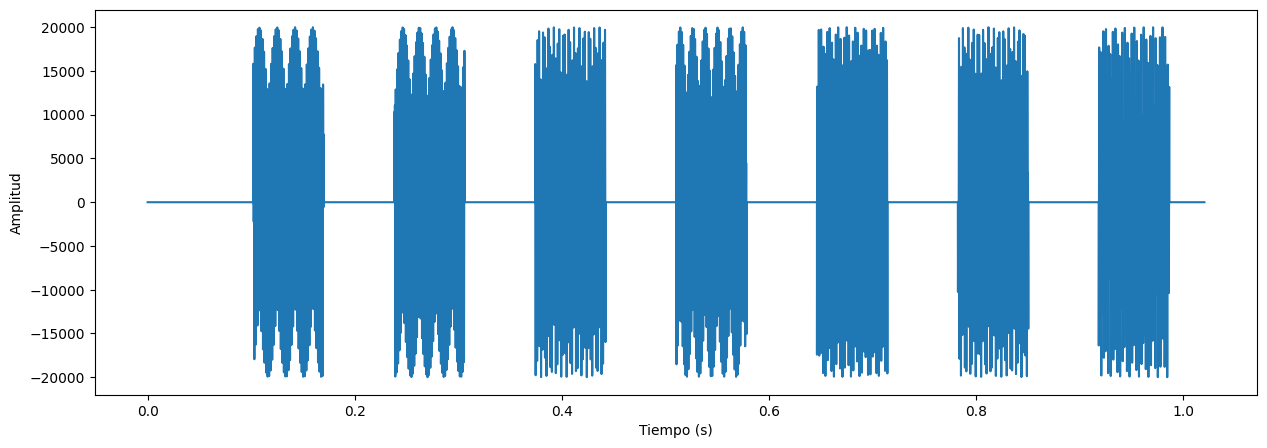

In [3]:
canal_a = audio_a[:,0]              # Me quedo con un canal
ta = np.arange(len(canal_a)) / fs_a

plt.figure(figsize=(15,5))
plt.plot(ta, canal_a)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

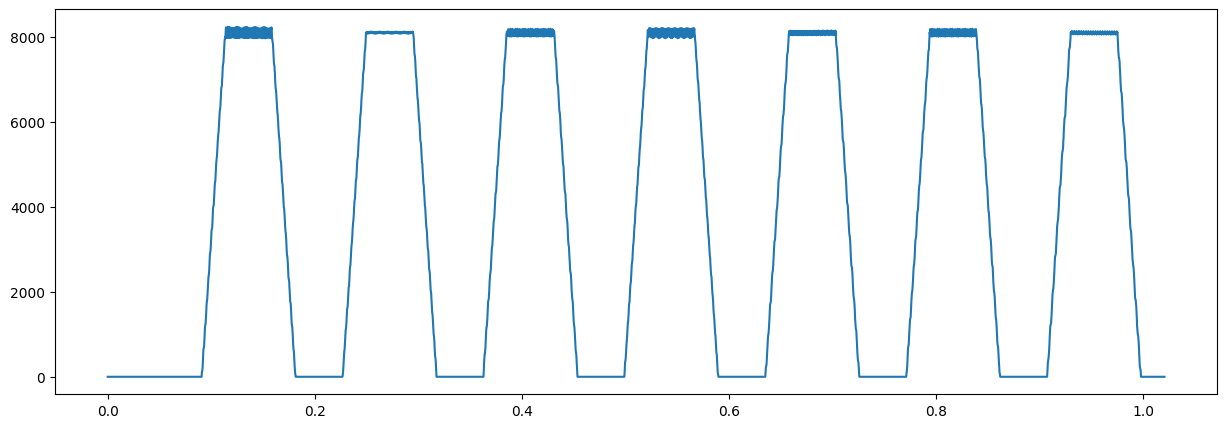

In [4]:
amplitud = np.abs(canal_a)

ventana = 1000

energia = np.convolve(
    amplitud,
    np.ones(ventana)/ventana,
    mode='same'
)

umbral = 3000

hay_senal = energia > umbral 

plt.figure(figsize=(15,5))

plt.plot(ta, energia)
#plt.plot(ta, hay_senal * np.max(canal_a))

plt.show()


In [5]:
cambios = np.diff(hay_senal.astype(int))

inicios = np.where(cambios == 1)[0]
finales = np.where(cambios == -1)[0]

tiempos_inicio = inicios / fs_a
tiempos_final = finales / fs_a

print(f'Tiempos inicio: {tiempos_inicio}')
print(f'Tiempos final: {tiempos_final}')

Tiempos inicio: [0.09943311 0.23507937 0.370839   0.50709751 0.64324263 0.77938776
 0.91562358]
Tiempos final: [0.17281179 0.30927438 0.44546485 0.58090703 0.71730159 0.85312925
 0.98909297]


Las frecuencias detectadas son: [ 695.02472188 1335.53770087]


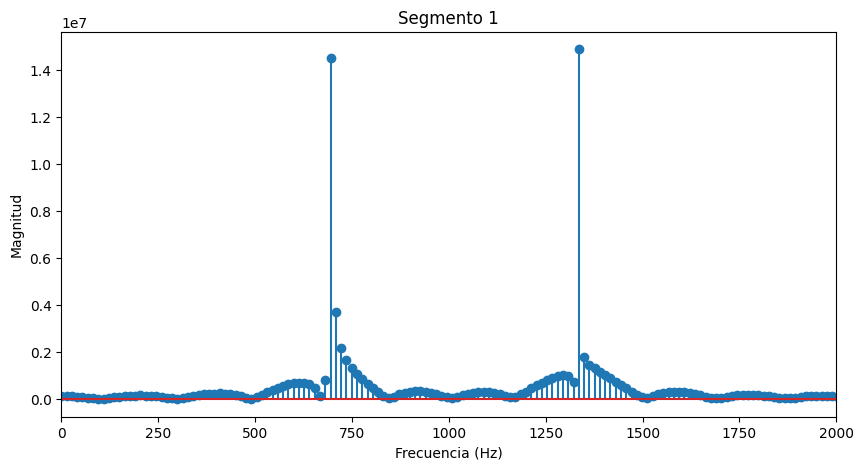

Las frecuencias detectadas son: [1482.5794621   768.24572127]


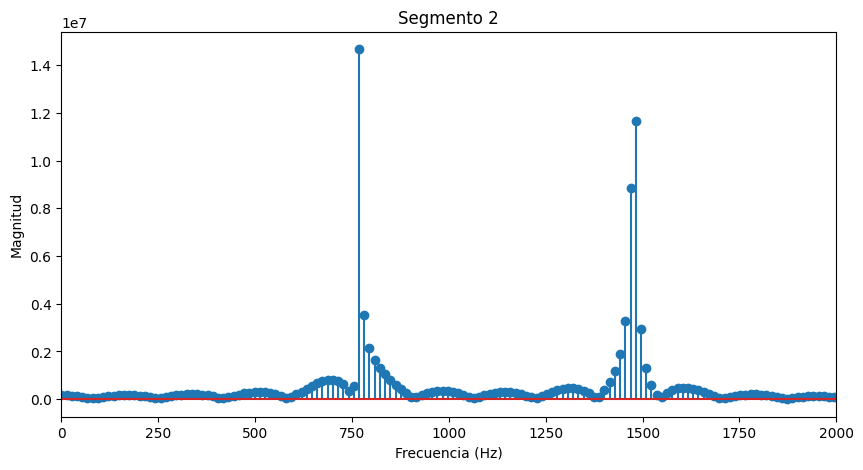

Las frecuencias detectadas son: [ 763.81039198 1340.01823154]


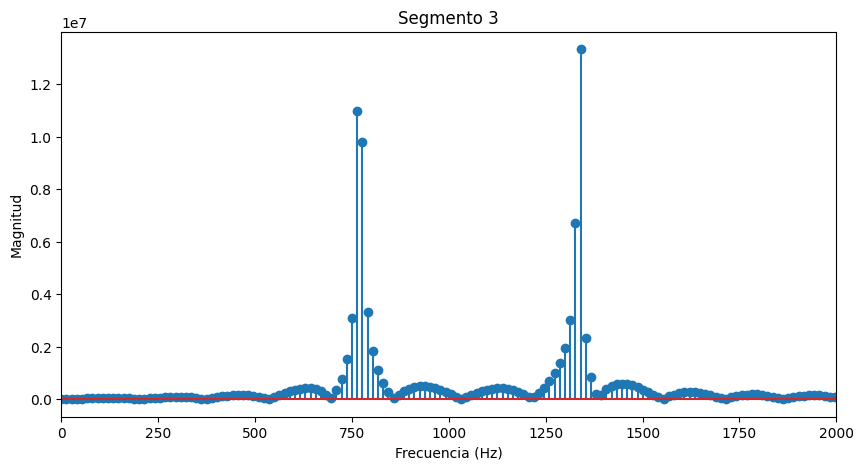

Las frecuencias detectadas son: [ 690.96774194 1476.77419355]


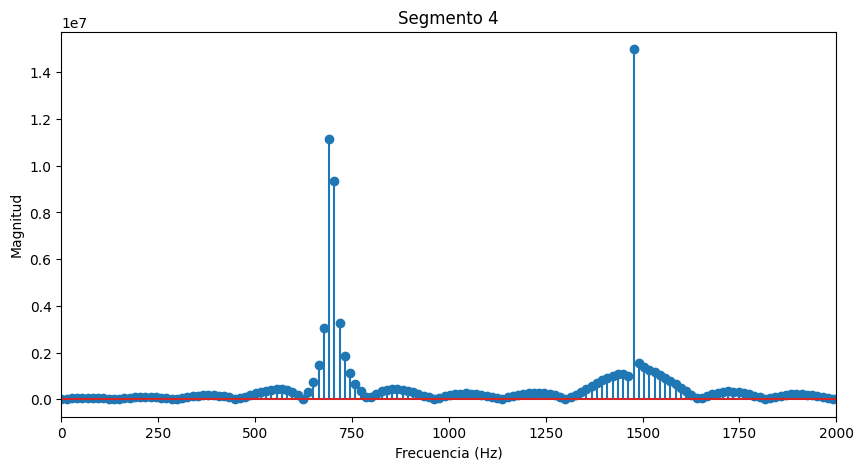

Las frecuencias detectadas son: [ 850.67360686 1336.77281078]


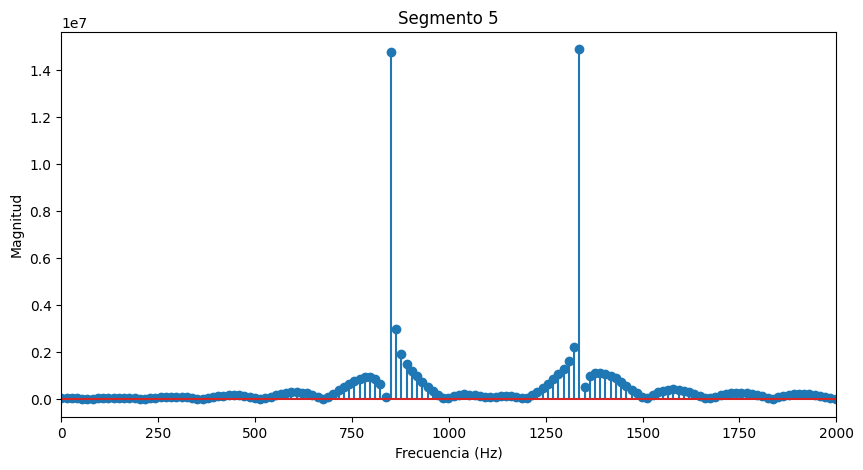

Las frecuencias detectadas son: [1342.52767528  772.9704797 ]


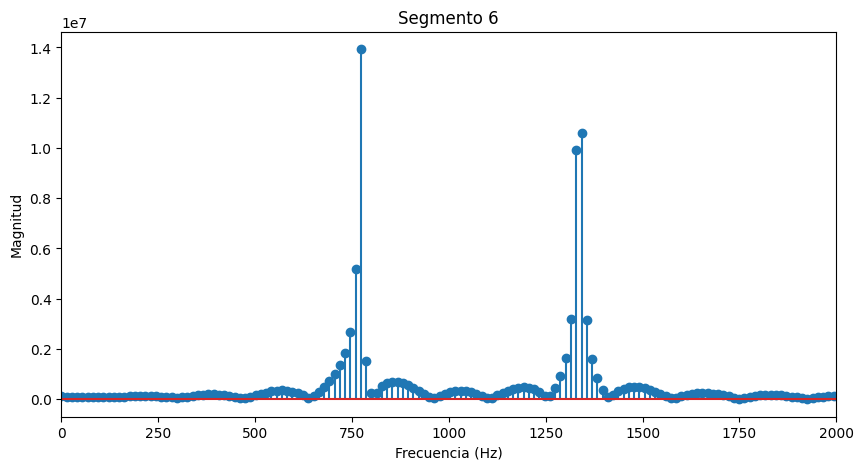

Las frecuencias detectadas son: [ 775.83333333 1211.38888889]


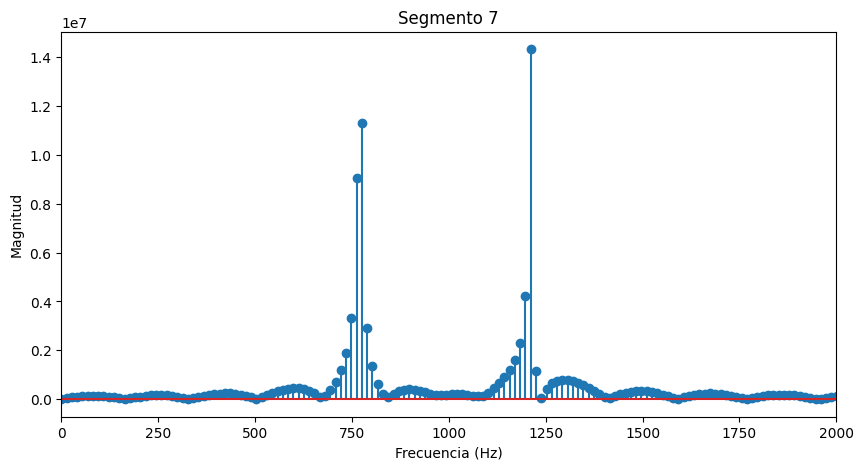

In [6]:
for i in range(len(inicios)):

    inicio = inicios[i]
    final = finales[i]

    segmento = canal_a[inicio:final]

    transformada = fft(segmento)

    frecuencias = fftfreq(len(segmento), d=1/fs_a)

    mitad = len(frecuencias)//2

    frecuencias = frecuencias[:mitad]
    magnitud = np.abs(transformada[:mitad])

    indices = np.argsort(magnitud)
    picos = indices[-2:]
    freq_detectadas = frecuencias[picos]

    print(f'Las frecuencias detectadas son: {freq_detectadas}')

    plt.figure(figsize=(10,5))

    plt.stem(frecuencias, magnitud)

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.title(f'Segmento {i+1}')
    plt.xlim(0, 2000)

    plt.show()

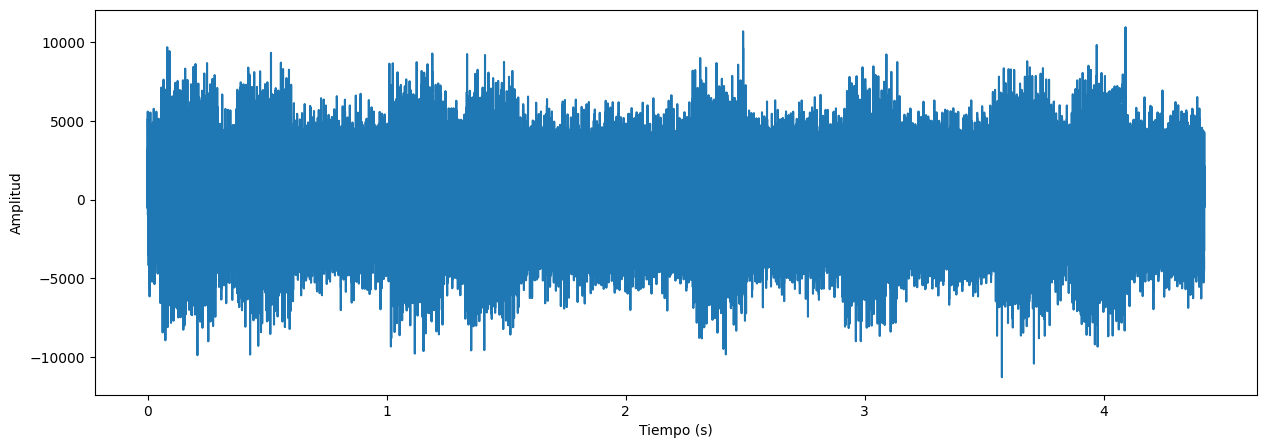

In [10]:
canal_b = audio_b[:,0]              # Me quedo con un canal
tb = np.arange(len(canal_b)) / fs_b

plt.figure(figsize=(15,5))
plt.plot(tb, canal_b)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.show()

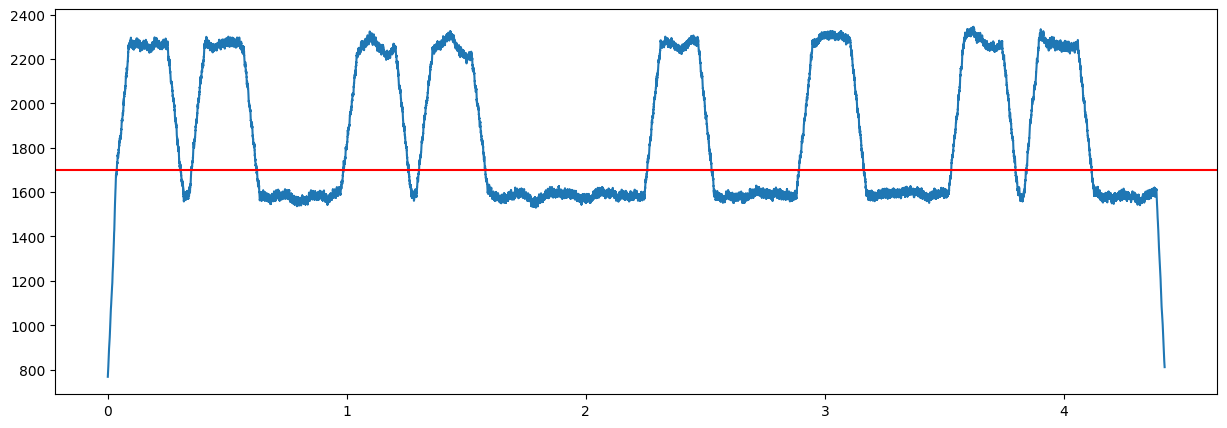

2345.316666666666
767.4713333333336


In [27]:
amplitud = np.abs(canal_b)

ventana = 3000

energia = np.convolve(
    amplitud,
    np.ones(ventana)/ventana,
    mode='same'
)

umbral = 1700

hay_senal = energia > umbral 

plt.figure(figsize=(15,5))
plt.plot(tb, energia)
plt.axhline(umbral, color='red')
plt.show()

print(np.max(energia))
print(np.min(energia))

In [28]:
cambios = np.diff(hay_senal.astype(int))

inicios = np.where(cambios == 1)[0]
finales = np.where(cambios == -1)[0]

duracion_minima = 0.05   # segundos

inicios_filtrados = []
finales_filtrados = []

for inicio, final in zip(inicios, finales):

    duracion = (final - inicio) / fs_b

    if duracion > duracion_minima:

        inicios_filtrados.append(inicio)
        finales_filtrados.append(final)

inicios = np.array(inicios_filtrados)
finales = np.array(finales_filtrados)

tiempos_inicio = inicios / fs_a
tiempos_final = finales / fs_a

print(f'Tiempos inicio: {tiempos_inicio}')
print(f'Tiempos final: {tiempos_final}')

Tiempos inicio: [0.03725624 0.34936508 0.98537415 1.30244898 2.25698413 2.89208617
 3.52888889 3.84412698]
Tiempos final: [0.30507937 0.6224263  1.25630385 1.57968254 2.52578231 3.16276644
 3.79768707 4.11609977]


Las frecuencias detectadas son: [1478.58775718  851.30810262]


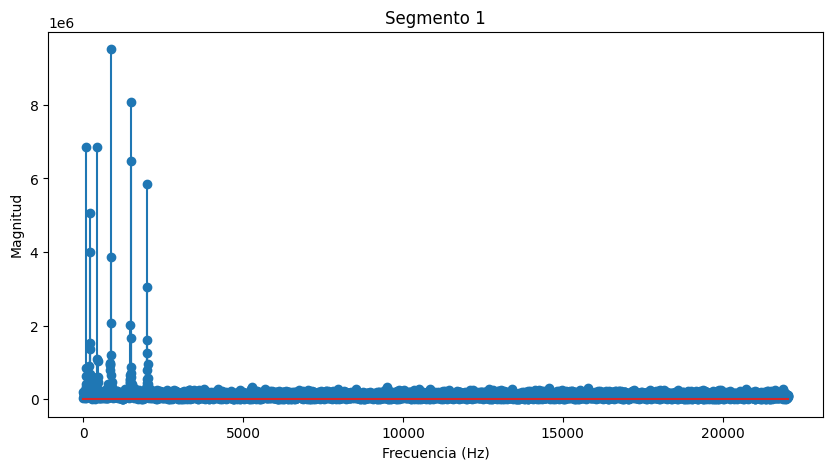

Las frecuencias detectadas son: [ 853.28849028 1208.52017937]


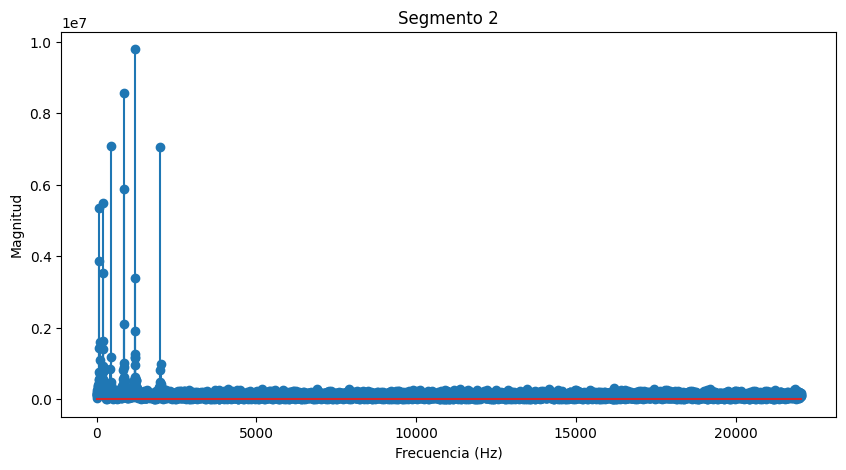

Las frecuencias detectadas son: [1210.64613324  852.6196853 ]


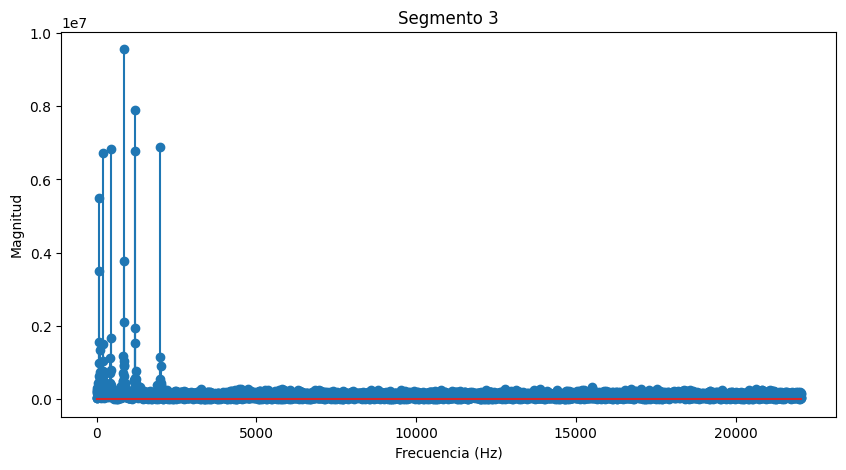

Las frecuencias detectadas son: [1475.2903648  768.3052511]


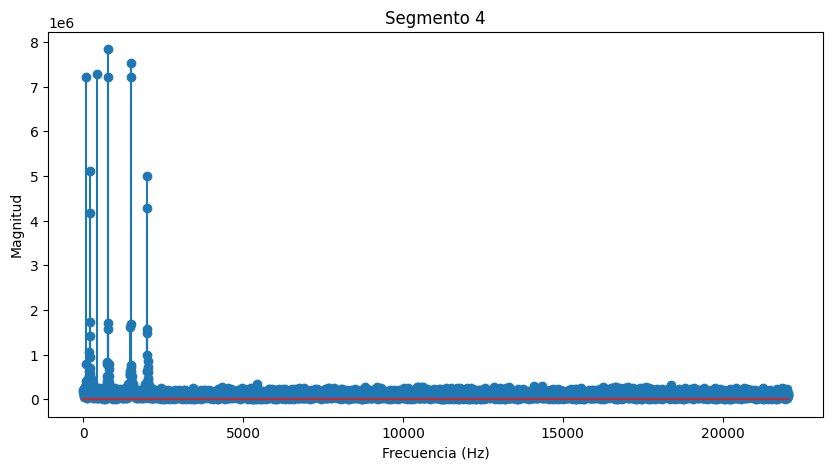

Las frecuencias detectadas son: [1335.57448962  851.94027333]


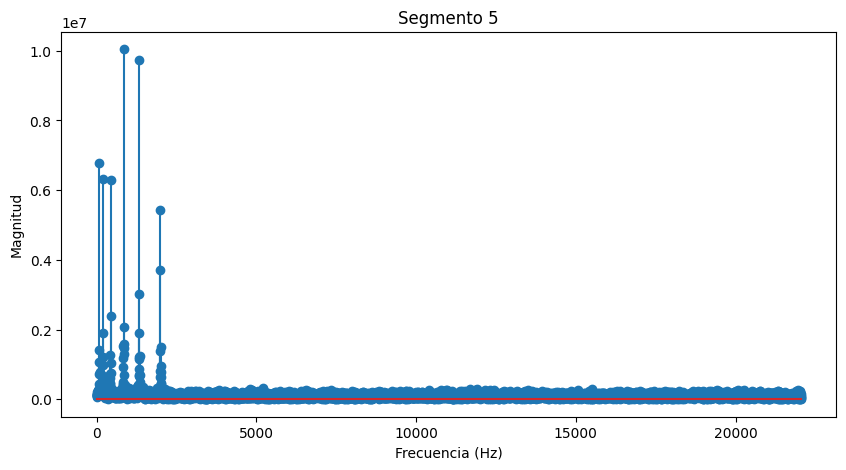

Las frecuencias detectadas son: [ 768.43427997 1208.06735361]


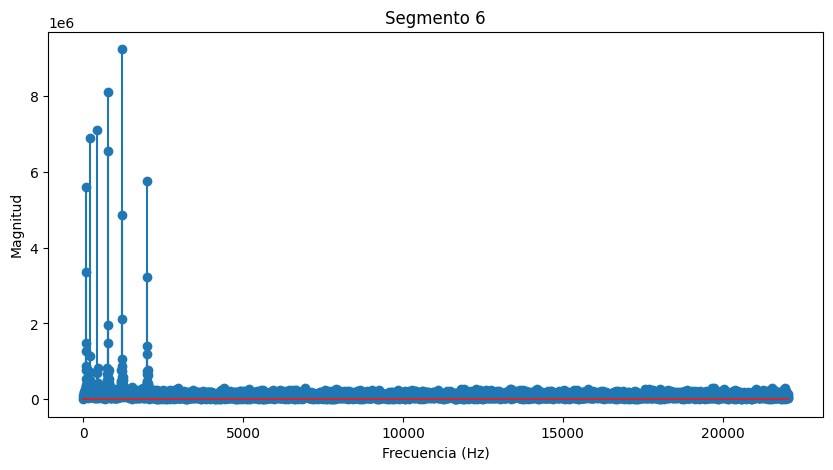

Las frecuencias detectadas son: [ 941.22659018 1335.57448962]


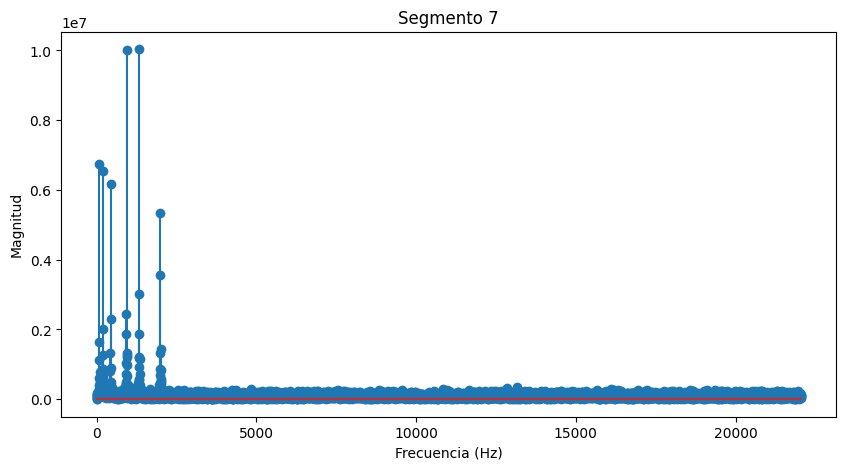

Las frecuencias detectadas son: [ 698.59929965 1478.08904452]


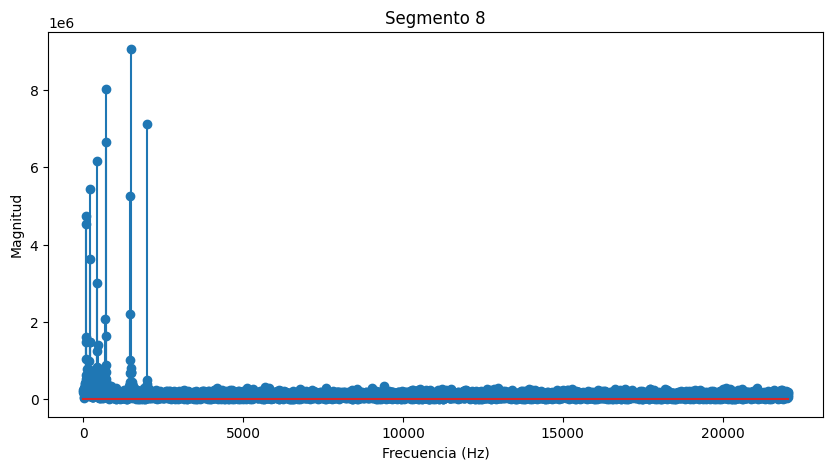

In [29]:
for i in range(len(inicios)):

    inicio = inicios[i]
    final = finales[i]

    segmento = canal_b[inicio:final]

    transformada = fft(segmento)

    frecuencias = fftfreq(len(segmento), d=1/fs_b)

    mitad = len(frecuencias)//2

    frecuencias = frecuencias[:mitad]
    magnitud = np.abs(transformada[:mitad])

    indices = np.argsort(magnitud)
    picos = indices[-2:]
    freq_detectadas = frecuencias[picos]

    print(f'Las frecuencias detectadas son: {freq_detectadas}')

    plt.figure(figsize=(10,5))

    plt.stem(frecuencias, magnitud)

    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Magnitud")
    plt.title(f'Segmento {i+1}')
    #plt.xlim(0, 2000)

    plt.show()